In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

In [2]:
mnist_dataset = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
(x_train, y_train), (x_test, y_test) = mnist_dataset
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

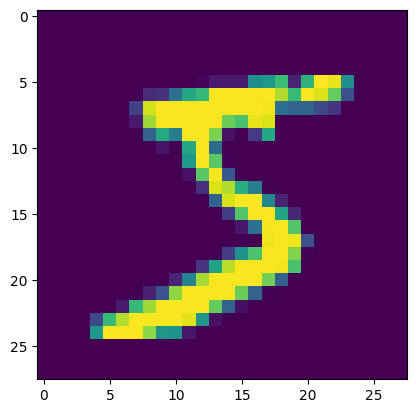

In [4]:
plt.imshow(x_train[0])

/tmp/ipykernel_184/2950142651.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(int(y_train[[RANDOM_INDEX]]))


Text(0.5, 1.0, '1')

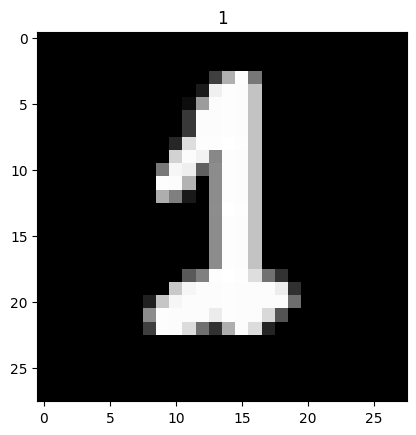

In [8]:
RANDOM_INDEX = np.random.randint(0, len(x_train))
plt.imshow(x_train[RANDOM_INDEX], cmap="gray");
plt.title(int(y_train[[RANDOM_INDEX]]))

Text(0.5, 1.0, 'Indexul ales este:3629')

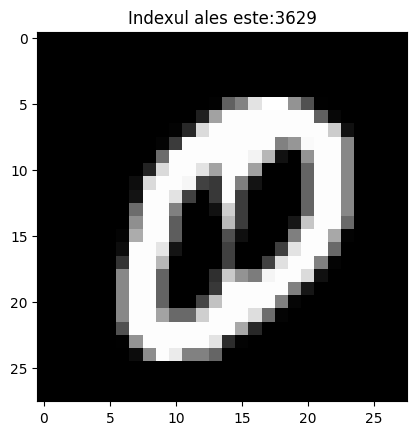

In [20]:
x_only_zeros = x_train[y_train == 0]
RANDOM_INDEX = np.random.randint(0, len(x_only_zeros))
plt.imshow(x_only_zeros[RANDOM_INDEX], cmap="gray");
plt.title(f"Indexul ales este:{RANDOM_INDEX}")

## 1. Crearea unui GAN (GENERATIVE ADVERSARIAL NETWORKS)

# GAN = Generator + Discriminator

In [21]:
generator = tf.keras.models.Sequential([])
discriminator = tf.keras.models.Sequential([])

GAN = tf.keras.models.Sequential([generator, discriminator])

#

# 2. Crearea unui discriminator

In [36]:
discriminator = tf.keras.models.Sequential([

        tf.keras.layers.Input(shape=(28, 28, 1)),

        tf.keras.layers.Flatten(),


       tf.keras.layers.Dense(200, activation="relu"),

       tf.keras.layers.Dense(100, activation="relu"),


       # Spune daca o imagine este corecta sau nu

       ## OUTPUT -> Intoarce o valoare intre 0 si 1. Daca este valida poza sau nu (1-> True, 0->False)
       tf.keras.layers.Dense(1, activation="sigmoid"), # o valoare intre 0 si 1 (0.2 = 20%)

])

discriminator.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
discriminator.trainable = False


In [24]:
generator = tf.keras.models.Sequential([])
discriminator = tf.keras.models.Sequential([])

GAN = tf.keras.models.Sequential([generator, discriminator])

# 3. Crearea unui generator - in oglinda cu discriminatorul

In [81]:
generator = tf.keras.models.Sequential([

      tf.keras.layers.Dense(100, activation="relu"),
      tf.keras.layers.Dense(200, activation="relu"),

      tf.keras.layers.Dense(28 * 28, activation="relu"),


      tf.keras.layers.Reshape((28, 28, 1)), # Changed from (28, 28) to (28, 28, 1)

])
GAN = tf.keras.models.Sequential([generator, discriminator])

In [78]:
GAN.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
GAN.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_18 (Sequential)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_13 (Sequential)      │ (32, 1)                │       177,201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,201 (692.19 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 177,201 (692.19 KB)

In [32]:
GAN.layers

[<Sequential name=sequential_4, built=False>,
 <Sequential name=sequential_5, built=False>]

In [30]:
GAN.layers[0].summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
GAN.layers[1].summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#

# Antrenare GAN-ului si a discriminatorului

In [40]:
x_only_zeros.shape

(5923, 28, 28)

In [41]:
x_train.shape

(60000, 28, 28)

In [42]:
tf.data.Dataset.from_tensor_slices(x_only_zeros)

<_TensorSliceDataset element_spec=TensorSpec(shape=(28, 28), dtype=tf.uint8, name=None)>

In [44]:
slice_data = tf.data.Dataset.from_tensor_slices(x_only_zeros)
slice_data

<_TensorSliceDataset element_spec=TensorSpec(shape=(28, 28), dtype=tf.uint8, name=None)>

In [46]:
batch_size = 32

# Imagini reale
new_slice_dataset = slice_data.batch(batch_size, drop_remainder=True).prefetch(1)
new_slice_dataset


<_PrefetchDataset element_spec=TensorSpec(shape=(32, 28, 28), dtype=tf.uint8, name=None)>

In [51]:
x_only_zeros[101]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,  45, 203, 254, 194,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,  37, 155, 249, 254, 254, 254,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  37, 158, 246, 254, 254, 254, 254, 232,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  35, 108, 237, 254, 244, 158,  44,  26, 191, 166,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  61, 243, 254, 254, 165,  41,   0,   0,   4, 196, 150,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  15,
        132, 240, 254, 232,  86,   5,   0,   0,   0,  91, 207,  41,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3, 181,
        254, 254, 237,  56,   0,   0,   0,   0,   0, 115, 148,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  58, 181, 254,
        254, 254,  52,   0,   0,   0,   0,   0,  27, 220,  17,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  39, 242, 254, 174,
        170, 251,   0,   0,   0,   0,   0,   0, 118, 145,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  49, 231, 254, 175,  19,
         30,  52,   0,   0,   0,   0,   0,  43, 220,  61,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  41, 246, 254, 146,  18,   0,
          0,   0,   0,   0,   0,   0,   0, 150, 170,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  20, 236, 254, 147,  17,   0,   0,
          0,   0,   0,   0,   0,   0,  98, 252, 116,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 204, 254, 131,   3,   0,   0,   0,
          0,   0,   0,   0,   0,  83, 234, 199,   4,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  90, 253, 153,  12,   0,   0,   0,   0,
          0,   0,   0,   0, 102, 233, 226,  74,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 212, 217,   9,   0,   0,   0,   0,   0,
          0,   0,  57, 186, 251, 181,  29,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 254, 111,   0,   0,   0,   0,   0,   0,
         29, 153, 240, 254, 148,  20,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 254, 142,   2,   0,  23,  39, 115, 181,
        239, 254, 237, 119,   4,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 255, 254, 197, 193, 245, 254, 254, 254,
        247, 145,  21,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 251, 254, 254, 254, 254, 254, 253, 178,
         68,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  79, 251, 193, 205, 166,  94,  71,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

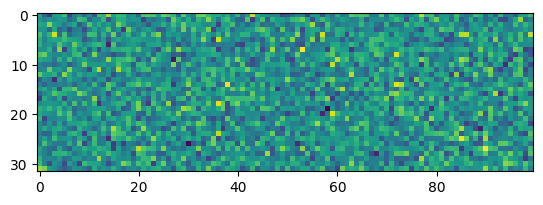

In [62]:
noise = tf.random.normal(shape=(batch_size, 100))
noise
plt.imshow(noise)

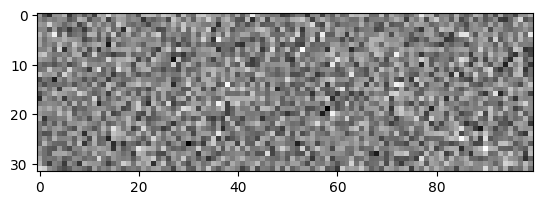

In [63]:
plt.imshow(noise, cmap="gray")

In [67]:
real_batch_of_data.shape

TensorShape([32, 28, 28])

In [75]:
batch_size

32

In [83]:
discriminator = tf.keras.models.Sequential([

        tf.keras.layers.Input(shape=(28, 28, 1)),

        tf.keras.layers.Flatten(),


       tf.keras.layers.Dense(200, activation="relu"),

       tf.keras.layers.Dense(100, activation="relu"),


       # Spune daca o imagine este corecta sau nu

       ## OUTPUT -> Intoarce o valoare intre 0 si 1. Daca este valida poza sau nu (1-> True, 0->False)
       tf.keras.layers.Dense(1, activation="sigmoid"), # o valoare intre 0 si 1 (0.2 = 20%)

])

discriminator.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
discriminator.trainable = False
generator = tf.keras.models.Sequential([

      tf.keras.layers.Dense(100, activation="relu"),
      tf.keras.layers.Dense(200, activation="relu"),

      tf.keras.layers.Dense(28 * 28, activation="relu"),


      tf.keras.layers.Reshape((28, 28, 1)), # Changed from (28, 28) to (28, 28, 1)

])
GAN = tf.keras.models.Sequential([generator, discriminator])
GAN.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [84]:
EPOCHS = 20

# Explicitly build the discriminator to ensure its input shape is defined
discriminator.build(input_shape=(None, 28, 28, 1))

for epoch in range(EPOCHS):
  print(f"Suntem in epoca: {epoch + 1}")

  # Iau imaginile reale + unele fake
  for real_batch_of_data in new_slice_dataset:

    # Generez o imagine fake
    noise = tf.random.normal(shape=(batch_size, 100))
    fake_images = generator(noise)

    float_real_batch_of_data = tf.cast(real_batch_of_data, tf.float32)
    # Add a channel dimension to real_batch_of_data to match fake_images
    float_real_batch_of_data = tf.expand_dims(float_real_batch_of_data, axis=-1)
    x_fake_and_real_images = tf.concat([fake_images, float_real_batch_of_data], axis=0)


    ## PAS 1 - Antrenare discriminator singur
    discriminator.trainable = True

    y_fake_and_real_images = tf.concat([tf.zeros(batch_size), tf.ones(batch_size)], axis=0)
    discriminator.train_on_batch(x_fake_and_real_images, y_fake_and_real_images)


    discriminator.trainable = False

    ## PAS 2 - Antrenare GAN (dar fara a schimba ponderile discriminatorul)
    y_GAN =   tf.constant([[1.]] * batch_size) # [1, 1, 1, 1, 1,]
    GAN.train_on_batch(noise, y_GAN)

Suntem in epoca: 1
Suntem in epoca: 2
Suntem in epoca: 3
Suntem in epoca: 4
Suntem in epoca: 5
Suntem in epoca: 6
Suntem in epoca: 7
Suntem in epoca: 8
Suntem in epoca: 9
Suntem in epoca: 10
Suntem in epoca: 11
Suntem in epoca: 12
Suntem in epoca: 13
Suntem in epoca: 14
Suntem in epoca: 15
Suntem in epoca: 16
Suntem in epoca: 17
Suntem in epoca: 18
Suntem in epoca: 19
Suntem in epoca: 20


In [85]:
noise = tf.random.normal(shape=(batch_size, 100))


generated_fake_images = generator(noise)
generated_fake_images.shape


TensorShape([32, 28, 28, 1])

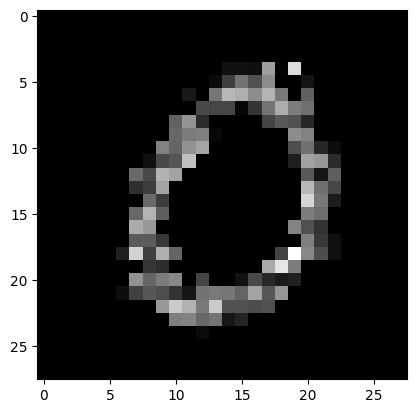

In [86]:
plt.imshow(generated_fake_images[0, :, :, 0], cmap="gray")

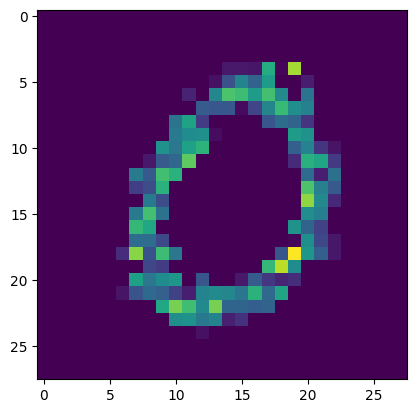

In [88]:
plt.imshow(generated_fake_images[0, :, :, 0])

In [89]:
discriminator = tf.keras.models.Sequential([

        tf.keras.layers.Input(shape=(28, 28, 1)),

        tf.keras.layers.Flatten(),


       tf.keras.layers.Dense(200, activation="relu"),

       tf.keras.layers.Dense(100, activation="relu"),


       # Spune daca o imagine este corecta sau nu

       ## OUTPUT -> Intoarce o valoare intre 0 si 1. Daca este valida poza sau nu (1-> True, 0->False)
       tf.keras.layers.Dense(1, activation="sigmoid"), # o valoare intre 0 si 1 (0.2 = 20%)

])

discriminator.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
discriminator.trainable = False
generator = tf.keras.models.Sequential([

      tf.keras.layers.Dense(100, activation="relu"),
      tf.keras.layers.Dense(200, activation="relu"),

      tf.keras.layers.Dense(28 * 28, activation="relu"),


      tf.keras.layers.Reshape((28, 28, 1)), # Changed from (28, 28) to (28, 28, 1)

])
GAN = tf.keras.models.Sequential([generator, discriminator])
GAN.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


EPOCHS = 80



for epoch in range(EPOCHS):
  print(f"Suntem in epoca: {epoch + 1}")

  # Iau imaginile reale + unele fake
  for real_batch_of_data in new_slice_dataset:

    # Generez o imagine fake
    noise = tf.random.normal(shape=(batch_size, 100))
    fake_images = generator(noise)

    float_real_batch_of_data = tf.cast(real_batch_of_data, tf.float32)
    # Add a channel dimension to real_batch_of_data to match fake_images
    float_real_batch_of_data = tf.expand_dims(float_real_batch_of_data, axis=-1)
    x_fake_and_real_images = tf.concat([fake_images, float_real_batch_of_data], axis=0)


    ## PAS 1 - Antrenare discriminator singur
    discriminator.trainable = True

    y_fake_and_real_images = tf.concat([tf.zeros(batch_size), tf.ones(batch_size)], axis=0)
    discriminator.train_on_batch(x_fake_and_real_images, y_fake_and_real_images)


    discriminator.trainable = False

    ## PAS 2 - Antrenare GAN (dar fara a schimba ponderile discriminatorul)
    y_GAN =   tf.constant([[1.]] * batch_size) # [1, 1, 1, 1, 1,]
    GAN.train_on_batch(noise, y_GAN)

Suntem in epoca: 1
Suntem in epoca: 2
Suntem in epoca: 3
Suntem in epoca: 4
Suntem in epoca: 5
Suntem in epoca: 6
Suntem in epoca: 7
Suntem in epoca: 8
Suntem in epoca: 9
Suntem in epoca: 10
Suntem in epoca: 11
Suntem in epoca: 12
Suntem in epoca: 13
Suntem in epoca: 14
Suntem in epoca: 15
Suntem in epoca: 16
Suntem in epoca: 17
Suntem in epoca: 18
Suntem in epoca: 19
Suntem in epoca: 20
Suntem in epoca: 21
Suntem in epoca: 22
Suntem in epoca: 23
Suntem in epoca: 24
Suntem in epoca: 25
Suntem in epoca: 26
Suntem in epoca: 27
Suntem in epoca: 28
Suntem in epoca: 29
Suntem in epoca: 30
Suntem in epoca: 31
Suntem in epoca: 32
Suntem in epoca: 33
Suntem in epoca: 34
Suntem in epoca: 35
Suntem in epoca: 36
Suntem in epoca: 37
Suntem in epoca: 38
Suntem in epoca: 39
Suntem in epoca: 40
Suntem in epoca: 41
Suntem in epoca: 42
Suntem in epoca: 43
Suntem in epoca: 44
Suntem in epoca: 45
Suntem in epoca: 46
Suntem in epoca: 47
Suntem in epoca: 48
Suntem in epoca: 49
Suntem in epoca: 50
Suntem in

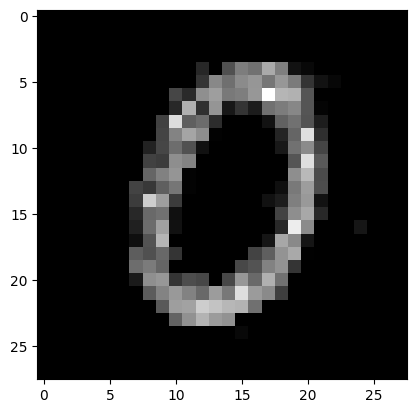

In [91]:
noise = tf.random.normal(shape=(batch_size, 100))


generated_fake_images = generator(noise)

plt.imshow(generated_fake_images[0, :, :, 0], cmap="gray")